# $P(\lambda_{ob} | \lambda_{true}, z_t)$ Comparison

Matteo made the optimization of memoizing the following integral:

$$
\int_{\Delta \lambda_{ob}} d\lambda_{ob} P(\lambda_{ob} | \lambda_{tr}, z_{tr})
$$

And interpolating over $\lambda_{tr}, z_{tr}$. Fortunately, he has data files of his results, so we can compare our $P(\lambda_{ob} | \lambda_{true}, z_{true})$ implementation.

In [1]:
lambda_bin_data = np.array([20, 27.9, 37.6, 50.3, 69.3, 140.0])
zt_int = np.linspace(0.0, 0.55, 56)
lt_int = np.linspace(1.0, 250, 250)

nlbin, nzbin, nltbin = len(lambda_bin_data), len(zt_int), len(lt_int)

int_PDF = np.zeros((nlbin - 1, nzbin - 1, nltbin - 1))
for n in range(nlbin - 1):
    int_PDF[n,:,:] = np.loadtxt('int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_{}_v27_0.dat'.format(n + 1))

data = [], [], [], []
for i, z in enumerate(zt_int[:-1]):
    for j, lt in enumerate(lt_int[:-1]):
        for _bin in range(nlbin - 1):
            data[0].append(_bin)
            data[1].append(z)
            data[2].append(lt)
            data[3].append(int_PDF[_bin, i, j])
        
df = pd.DataFrame({'bin': data[0], 'zt': data[1], 'lt': data[2], 'lc_lt_integrated': data[3]})
df[df['lt'] == 100].dropna()

,bin,zt,lt,lc_lt_integrated
495,0,0.00,100.0,0.000000
496,1,0.00,100.0,0.000000
497,2,0.00,100.0,0.000600
498,3,0.00,100.0,0.000400
499,4,0.00,100.0,0.930000
1740,0,0.01,100.0,0.000000
1741,1,0.01,100.0,0.000000
1742,2,0.01,100.0,0.000600
1743,3,0.01,100.0,0.000400
1744,4,0.01,100.0,0.930000


# Comparison to Our integrals

We compare to tables of our integrations, computed from the `./test/integrate_lc_lt` executable.

(0, 50)

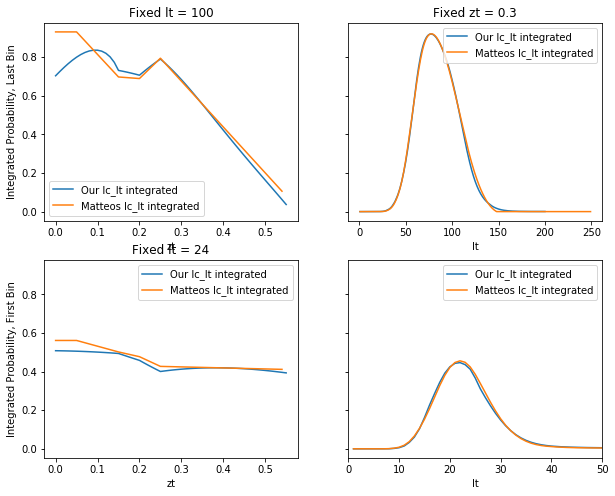

In [2]:
# First, make our plots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]
ax1.set_ylabel('Integrated Probability, Last Bin')
ax3.set_ylabel('Integrated Probability, First Bin')

fixed_lt_slice = df[(df['lt'] == 100) & (df['bin'] == 4)].dropna()
our_fixed_lt_slice = pd.read_csv('int_P_lob_ltr/our_data/last_bin_lambda_100.csv')

fixed_zt_slice = df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 4)].dropna()
our_fixed_zt_slice = pd.read_csv('int_P_lob_ltr/our_data/last_bin_zt_0_3.csv')

our_fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax1)
fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax1)

our_fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax2)
fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax2)

ax1.set_title('Fixed lt = 100')
ax2.set_title('Fixed zt = 0.3')

fixed_lt_slice = df[(df['lt'] == 24) & (df['bin'] == 0)].dropna()
our_fixed_lt_slice = pd.read_csv('int_P_lob_ltr/our_data/first_bin_lambda_24.csv')

fixed_zt_slice = df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 0)].dropna()
our_fixed_zt_slice = pd.read_csv('int_P_lob_ltr/our_data/first_bin_zt_0_3.csv')

our_fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax3)
fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax3)

our_fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax4)
fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax4)

ax3.set_title('Fixed lt = 24')
ax4.set_xlim((0, 50))

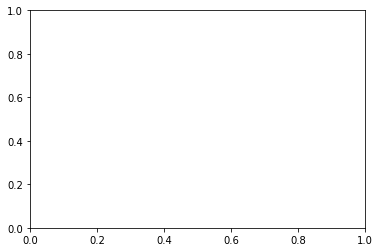

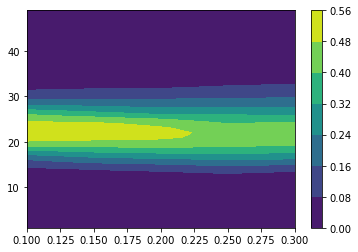

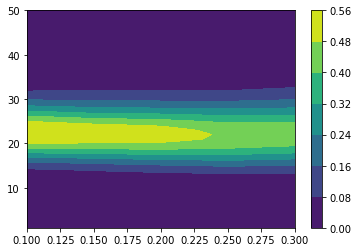

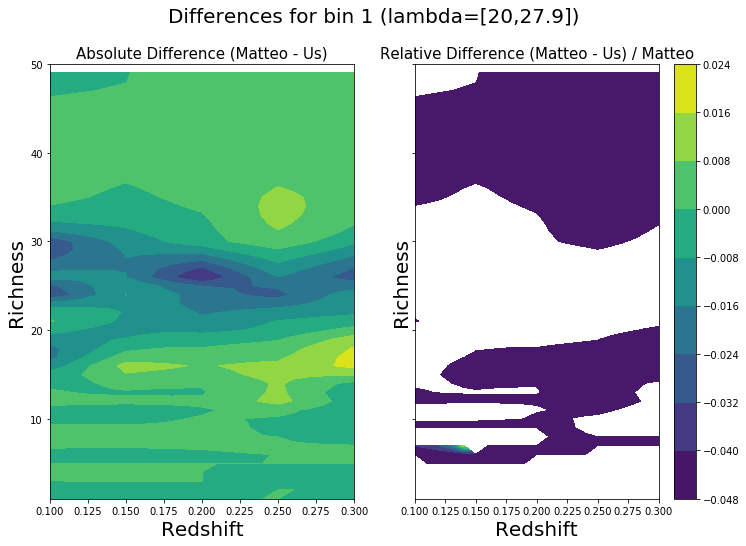

In [3]:
# Get our data on a grid
our_data_grid = pd.read_csv('int_P_lob_ltr/our_data/first_bin_grid.csv')
our_data_grid = our_data_grid[our_data_grid['lt'] < 50].dropna()

# Get matteos data on the same grid
matteos_data_grid = df[(df['lt'] <= 50) &
                       (df['zt'] >= 0.1) & (df['zt'] <= 0.3) &
                       (df['bin'] == 0)].dropna()

matteos_data_grid

def plot_contour(data2d, ax=plt.gca(), xlabel=None, ylabel=None, vmin=None, vmax=None):
    X = data2d.columns.values
    Y = data2d.index.values
    Z = data2d.values
    x, y = np.meshgrid(X, Y)
    
    ret = ax.contourf(x, y, Z, vmin=vmin, vmax=vmax)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=20)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=20)
    return ret

our_data_grid = our_data_grid.pivot('lt', 'zt', 'lc_lt_integrated')
matteos_data_grid = matteos_data_grid.pivot('lt', 'zt', 'lc_lt_integrated')

plt.figure('Our grid')
map_ = plot_contour(our_data_grid, ax=plt.gca())
plt.colorbar(map_)

plt.figure('Matteos grid')
map_ = plot_contour(matteos_data_grid, ax=plt.gca())
plt.colorbar(map_)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)
fig.suptitle('Differences for bin 1 (lambda=[20,27.9])', fontsize=20)
ax1.set_title('Absolute Difference (Matteo - Us)', fontsize=15)
map_ = plot_contour(our_data_grid - matteos_data_grid, ax=ax1,
                    xlabel='Redshift', ylabel='Richness')
ax2.set_title('Relative Difference (Matteo - Us) / Matteo', fontsize=15)
plot_contour((our_data_grid - matteos_data_grid) / matteos_data_grid, ax=ax2,
             xlabel='Redshift', ylabel='Richness')
fig.colorbar(map_)

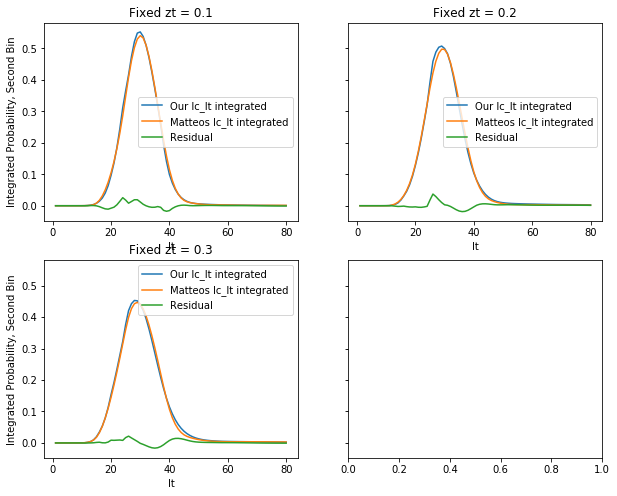

In [4]:
# First, make our plots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]
ax1.set_ylabel('Integrated Probability, Second Bin')
ax3.set_ylabel('Integrated Probability, Second Bin')

matteos_zt = [df[((df['zt'] - 0.1).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna(),
              df[((df['zt'] - 0.2).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna(),
              df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna()]
our_zt = [pd.read_csv('int_P_lob_ltr/our_data/second_bin_zt_0_{}.csv'.format(i))
          for i in (1, 2, 3)]

ax1.set_title('Fixed zt = 0.1')
our_zt[0].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax1)
matteos_zt[0].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax1)
ax1.plot(our_zt[0]['lt'], np.array(our_zt[0]['lc_lt_integrated']) - np.array(matteos_zt[0]['lc_lt_integrated']),
         label='Residual')
ax1.legend()

ax2.set_title('Fixed zt = 0.2')
our_zt[1].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax2)
matteos_zt[1].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax2)
ax2.plot(our_zt[1]['lt'], np.array(our_zt[1]['lc_lt_integrated']) - np.array(matteos_zt[1]['lc_lt_integrated']),
         label='Residual')
ax2.legend()

ax3.set_title('Fixed zt = 0.3')
our_zt[2].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax3)
matteos_zt[2].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax3)
ax3.plot(our_zt[2]['lt'], np.array(our_zt[2]['lc_lt_integrated']) - np.array(matteos_zt[2]['lc_lt_integrated']),
         label='Residual')
ax3.legend()